<a href="https://www.kaggle.com/code/mendelowitzadi/isic2018-task3-classification?scriptVersionId=317792022" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# ISIC 2018 Task 3: Skin Lesion Classification with EfficientNet-B0

7-class skin lesion classification fine-tuned from ImageNet-pretrained EfficientNet-B0.

**Dataset:** HAM10000 — Human Against Machine with 10000 training images  
**Reference:** Tschandl et al., Scientific Data, 2018. https://doi.org/10.1038/sdata.2018.161  
**Challenge:** Codella et al., ISIC 2018, arXiv:1902.03368, 2019  
**Kaggle dataset:** `kmader/skin-cancer-mnist-ham10000`

**Primary metric:** Balanced accuracy (mean per-class recall), per Codella et al. (2019).  
Standard accuracy is not used because NV accounts for 67% of training images.

**Class imbalance handling:** Weighted cross-entropy with per-class weights  
`weight_c = total_samples / (num_classes * count_c)`.

## 1. Imports and configuration

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.utils.data
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from PIL import Image
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Configuration
# ============================================================
BASE = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")

IMG_DIRS = [BASE / "HAM10000_images_part_1", BASE / "HAM10000_images_part_2"]

CFG = {
    "img_dirs":     IMG_DIRS,
    "metadata":     BASE / "HAM10000_metadata.csv",
    "ckpt_dir":     Path("/kaggle/working/checkpoints"),
    # Data
    "val_fraction": 0.2,
    "img_size":     224,
    "seed":         42,
    # Training
    "num_classes":  7,
    "batch_size":   32,
    "num_epochs":   20,
    "freeze_epochs": 5,
    "lr":           3e-4,
    "weight_decay": 1e-3,
    "resume_ckpt":  None,
}

CFG["ckpt_dir"].mkdir(parents=True, exist_ok=True)

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
torch.cuda.manual_seed_all(CFG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Dataset

In [3]:
# ============================================================
# Dataset
# ============================================================
CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}


def build_image_index(img_dirs: list[Path]) -> dict[str, Path]:
    """
    Builds a mapping from image_id to full file path by scanning all image directories.
    HAM10000 splits images across two part directories.

    Args:
        img_dirs: List of directories containing ISIC_XXXXXXX.jpg files.

    Returns:
        Dict mapping image_id (e.g. 'ISIC_0024306') to its Path.
    """
    index = {}
    for d in img_dirs:
        for p in d.glob("*.jpg"):
            index[p.stem] = p
    return index


class ISICClassificationDataset(torch.utils.data.Dataset):
    """
    HAM10000 skin lesion classification dataset.

    Args:
        records:   DataFrame with columns ['image_id', 'dx'] for this split.
        img_index: Dict mapping image_id to file path (from build_image_index).
        transform: Albumentations Compose transform applied to each image.

    Returns:
        (image_tensor, label) pairs where label is an integer in [0, 6].
    """

    def __init__(self, records: pd.DataFrame, img_index: dict[str, Path], transform: A.Compose) -> None:
        self.records = records.reset_index(drop=True)
        self.img_index = img_index
        self.transform = transform

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self.records.iloc[idx]
        image = np.array(Image.open(self.img_index[row["image_id"]]).convert("RGB"))
        # .clone() forces tensor memory ownership required by multi-worker DataLoader collation.
        return self.transform(image=image)["image"].clone(), CLASS_TO_IDX[row["dx"]]

In [4]:
# ============================================================
# DataLoaders
# ============================================================
def build_dataloaders(cfg: dict) -> tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader, torch.Tensor]:
    """
    Build train and validation DataLoaders with a lesion-level stratified split.

    The split is on lesion_id, not image_id, because the same lesion appears multiple times in HAM10000 with different crops. 
    Splitting on image_id leaks lesion information into validation and inflates metrics.

    Returns:
        (train_loader, val_loader, class_weights)
        class_weights is a FloatTensor of shape (num_classes,) for use with CrossEntropyLoss.
    """
    meta = pd.read_csv(cfg["metadata"])
    img_index = build_image_index(cfg["img_dirs"])

    lesion_df = meta.drop_duplicates("lesion_id")[["lesion_id", "dx"]]
    train_lesions, val_lesions = train_test_split(lesion_df["lesion_id"].values, test_size=cfg["val_fraction"],
                                                  stratify=lesion_df["dx"].values, random_state=cfg["seed"])
    train_records = meta[meta["lesion_id"].isin(set(train_lesions))]
    val_records   = meta[meta["lesion_id"].isin(set(val_lesions))]

    class_counts = train_records["dx"].value_counts()
    total = len(train_records)
    weights = torch.tensor(
        [total / (cfg["num_classes"] * class_counts[c]) for c in CLASSES],
        dtype=torch.float32,
    )

    mean  = (0.485, 0.456, 0.406)
    std   = (0.229, 0.224, 0.225)
    im_sz = cfg["img_size"]

    train_transform = A.Compose([
        A.Resize(height=im_sz, width=im_sz),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=180, p=0.8), # Lesion orientation is arbitrary across dermoscopy acquisitions.
        # Simulates variation in camera-to-lesion distance. Always outputs a fixed size, avoiding collation size mismatches.
        A.RandomResizedCrop(size=(im_sz, im_sz), scale=(0.7, 1.0), p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05, p=0.7),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.3),         # ISONoise simulates dermoscopy camera sensor noise.
        # CoarseDropout simulates hair and ruler artefacts (Codella et al., 2019).
        A.CoarseDropout(
            num_holes_range=(1, 6),
            hole_height_range=(8, 24),
            hole_width_range=(8, 24),
            fill=0,
            p=0.3,
        ),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])
    val_transform = A.Compose([
        A.Resize(height=im_sz, width=im_sz),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])

    train_ds = ISICClassificationDataset(train_records, img_index, train_transform)
    val_ds   = ISICClassificationDataset(val_records, img_index, val_transform)

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=cfg["batch_size"], shuffle=True,
        num_workers=2, pin_memory=True, drop_last=True,
    )
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=cfg["batch_size"], shuffle=False,
        num_workers=2, pin_memory=True,
    )

    print(f"Train: {len(train_ds)} images | Val: {len(val_ds)} images")
    print("Class weights:")
    for c, w in zip(CLASSES, weights):
        print(f"  {c:6s}: {w:.3f}")

    return train_loader, val_loader, weights


train_loader, val_loader, class_weights = build_dataloaders(CFG)
class_weights = class_weights.to(DEVICE)

Train: 8020 images | Val: 1995 images
Class weights:
  akiec : 4.323
  bcc   : 2.767
  bkl   : 1.300
  df    : 13.169
  mel   : 1.280
  nv    : 0.213
  vasc  : 10.416


## 3. Dataset sanity check

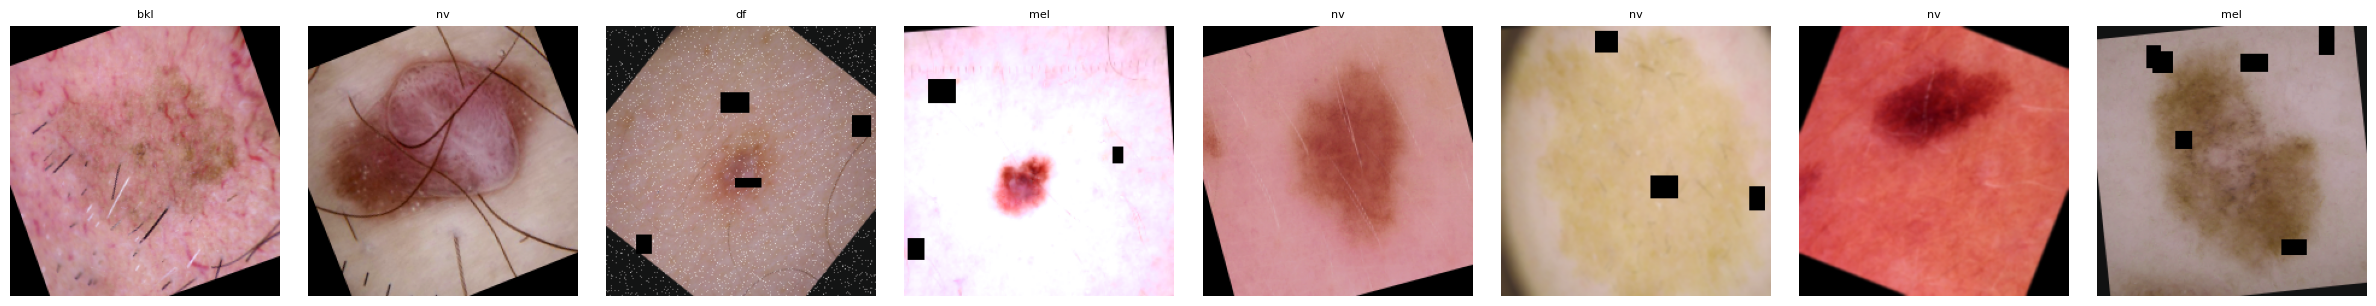

In [5]:
def visualise_samples(loader: torch.utils.data.DataLoader, n: int = 8) -> None:
    """Plot n training images with their class labels."""
    images, labels = next(iter(loader))
    n = min(n, len(images))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, img, lbl in zip(axes, images[:n], labels[:n]):
        img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(CLASSES[lbl.item()], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


visualise_samples(train_loader, n=8)

## 4. Model

In [6]:
# ============================================================
# Model
# ============================================================
def build_model(num_classes: int) -> nn.Module:
    """
    Load EfficientNet-B0 pretrained on ImageNet with the classification head replaced for num_classes output 
    classes and drop_rate=0.4 per Tan and Le (2019).

    Args:
        num_classes: Number of output classes.

    Returns:
        EfficientNet-B0 model ready for fine-tuning.
    """
    return timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes, drop_rate=0.4)


model = build_model(CFG["num_classes"]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Trainable parameters: 4,016,515


## 5. Training and evaluation

In [7]:
# ============================================================
# Training
# ============================================================
def train_one_epoch(model: nn.Module, loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer,
                    criterion: nn.Module) -> float:
    """
    Run one training epoch.

    Args:
        model: Model in train mode.
        loader: Training DataLoader.
        optimizer: Optimizer.
        criterion: Weighted CrossEntropyLoss.

    Returns:
        Mean loss over the epoch.
    """
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model: nn.Module, loader: torch.utils.data.DataLoader, criterion: nn.Module) -> tuple[float, float, float]:
    """
    Evaluate model on a DataLoader.

    Predictions and labels are accumulated across the full set before computing balanced accuracy to avoid 
    per-batch class distribution artefacts.

    Args:
        model: Model in eval mode.
        loader: DataLoader.
        criterion: Loss function.

    Returns:
        Tuple of (mean_loss, accuracy, balanced_accuracy).
    """
    model.eval()
    all_preds:  list[np.ndarray] = []
    all_labels: list[np.ndarray] = []
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        total_loss += criterion(logits, labels).item()
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return (
        total_loss / len(loader),
        float((all_preds == all_labels).mean()),
        float(balanced_accuracy_score(all_labels, all_preds)),
    )


def _set_backbone_grad(model: nn.Module, requires_grad: bool) -> None:
    """Freeze or unfreeze all parameters except the EfficientNet classifier head."""
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = requires_grad


def train(model: nn.Module, train_loader: torch.utils.data.DataLoader, val_loader: torch.utils.data.DataLoader,
          class_weights: torch.Tensor, cfg: dict) -> dict:
    """
    Training loop with progressive unfreezing and cosine LR decay.

    Phase 1 (epochs 1..freeze_epochs): backbone frozen, head trained at lr_head.
    Phase 2 (epochs freeze_epochs+1..num_epochs): full network trained at lr with
    a fresh cosine schedule over the remaining epochs.

    Best checkpoint is saved by validation balanced accuracy (Codella et al., 2019).

    Args:
        model:         EfficientNet-B0 model.
        train_loader:  Training DataLoader.
        val_loader:    Validation DataLoader.
        class_weights: Per-class loss weights on DEVICE.
        cfg:           Configuration dict.

    Returns:
        History dict with keys train_loss, val_loss, val_acc, val_bal_acc.
    """
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    freeze_epochs = cfg["freeze_epochs"]
    total_epochs = cfg["num_epochs"]
    

    _set_backbone_grad(model, False)
    # Phase 1: head-only. Higher LR because the head has random init weights
    # and needs to reach a reasonable solution before the backbone unfreezes.
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.get("lr_head", 1e-3),
        weight_decay=cfg["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=freeze_epochs, eta_min=1e-5,
    )

    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_acc": [], "val_bal_acc": []}
    best_bal_acc, start_epoch = 0.0, 1

    if cfg.get("resume_ckpt") and Path(cfg["resume_ckpt"]).exists():
        ckpt = torch.load(cfg["resume_ckpt"], map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        best_bal_acc = ckpt["val_bal_acc"]
        start_epoch  = ckpt["epoch"] + 1
        for _ in range(ckpt["epoch"]):
            scheduler.step()
        print(f"Resumed from epoch {ckpt['epoch']} (val_bal_acc={best_bal_acc:.4f})")

    final_epoch = start_epoch + total_epochs - 1  # display denominator
    for epoch in range(start_epoch, start_epoch + total_epochs):
        if epoch == freeze_epochs + 1:
            _set_backbone_grad(model, True)
            # Phase 2: full network. Standard LR - backbone has pretrained weights and doesn't need to be treated as randomly initialised.
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"],
            )
            remaining = total_epochs - freeze_epochs
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=remaining, eta_min=1e-6,
            )
            print(f"  Backbone unfrozen at epoch {epoch}.")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        scheduler.step()
        val_loss, val_acc, val_bal_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_bal_acc"].append(val_bal_acc)

        print(
            f"Epoch {epoch:02d}/{total_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_bal_acc={val_bal_acc:.4f}"
        )

        if val_bal_acc > best_bal_acc:
            best_bal_acc = val_bal_acc
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_bal_acc": best_bal_acc,
                },
                cfg["ckpt_dir"] / "best_efficientnet_b0_ham10000.pth",
            )
            print(f"  Checkpoint saved (val_bal_acc={best_bal_acc:.4f})")

    print(f"\nTraining complete. Best val balanced accuracy: {best_bal_acc:.4f}")
    return history


CFG["lr_head"]       = 1e-3
CFG["freeze_epochs"] = 5
CFG["num_epochs"]    = 25
CFG["resume_ckpt"]   = None

history = train(model, train_loader, val_loader, class_weights, CFG)

Epoch 01/25 | train_loss=4.3876 | val_loss=2.1842 | val_acc=0.3980 | val_bal_acc=0.2650
  Checkpoint saved (val_bal_acc=0.2650)
Epoch 02/25 | train_loss=3.6834 | val_loss=1.9469 | val_acc=0.4341 | val_bal_acc=0.3391
  Checkpoint saved (val_bal_acc=0.3391)
Epoch 03/25 | train_loss=3.1525 | val_loss=1.7769 | val_acc=0.4817 | val_bal_acc=0.3820
  Checkpoint saved (val_bal_acc=0.3820)
Epoch 04/25 | train_loss=3.0539 | val_loss=1.7637 | val_acc=0.4857 | val_bal_acc=0.3968
  Checkpoint saved (val_bal_acc=0.3968)
Epoch 05/25 | train_loss=2.9802 | val_loss=1.7136 | val_acc=0.4932 | val_bal_acc=0.3933
  Backbone unfrozen at epoch 6.
Epoch 06/25 | train_loss=1.8890 | val_loss=1.2484 | val_acc=0.5870 | val_bal_acc=0.6156
  Checkpoint saved (val_bal_acc=0.6156)
Epoch 07/25 | train_loss=1.2409 | val_loss=1.0165 | val_acc=0.6331 | val_bal_acc=0.6276
  Checkpoint saved (val_bal_acc=0.6276)
Epoch 08/25 | train_loss=1.1797 | val_loss=0.9519 | val_acc=0.6561 | val_bal_acc=0.6633
  Checkpoint saved (val_

## 6. Training curves

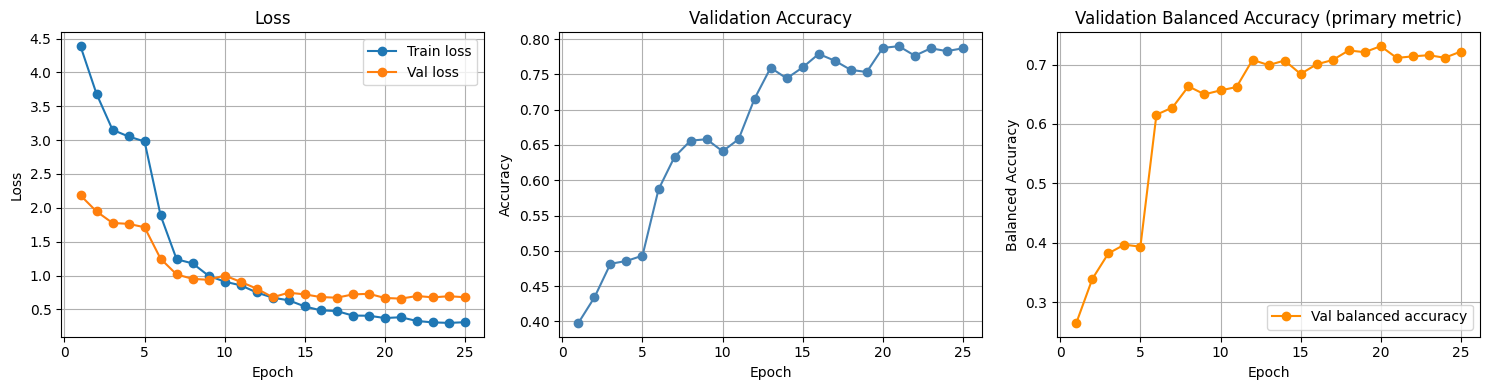

In [8]:
# ============================================================
# Training curves
# ============================================================
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train loss")
axes[0].plot(epochs, history["val_loss"],   marker="o", label="Val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["val_acc"], marker="o", color="steelblue")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].grid(True)

axes[2].plot(epochs, history["val_bal_acc"], marker="o", color="darkorange", label="Val balanced accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Balanced Accuracy")
axes[2].set_title("Validation Balanced Accuracy (primary metric)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(Path("/kaggle/working") / "training_curves_task3.png", dpi=150)
plt.show()

## 7. Per-class evaluation on validation set

In [9]:
# Load best checkpoint
ckpt = torch.load(CFG["ckpt_dir"] / "best_efficientnet_b0_ham10000.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
      f"(val_bal_acc={ckpt['val_bal_acc']:.4f})")


@torch.no_grad()
def per_class_report(model: nn.Module, loader: torch.utils.data.DataLoader) -> None:
    """Print per-class recall (the component terms of balanced accuracy)."""
    model.eval()
    all_preds:  list[np.ndarray] = []
    all_labels: list[np.ndarray] = []

    for images, labels in loader:
        logits = model(images.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    print(f"{'Class':8s} {'Recall':>8s} {'N val':>8s}")
    print("-" * 28)
    for i, cls in enumerate(CLASSES):
        mask   = all_labels == i
        recall = float((all_preds[mask] == i).mean()) if mask.any() else 0.0
        print(f"{cls:8s} {recall:8.4f} {mask.sum():8d}")
    print("-" * 28)
    print(f"{'Bal acc':8s} {balanced_accuracy_score(all_labels, all_preds):8.4f}")


per_class_report(model, val_loader)

Loaded checkpoint from epoch 20 (val_bal_acc=0.7310)
Class      Recall    N val
----------------------------
akiec      0.6935       62
bcc        0.7300      100
bkl        0.6835      218
df         0.6786       28
mel        0.6147      218
nv         0.8414     1337
vasc       0.8750       32
----------------------------
Bal acc    0.7310


In [10]:
# ============================================================
# Per-class evaluation
# ============================================================
ckpt = torch.load(CFG["ckpt_dir"] / "best_efficientnet_b0_ham10000.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val_bal_acc={ckpt['val_bal_acc']:.4f})")


@torch.no_grad()
def per_class_report(model: nn.Module, loader: torch.utils.data.DataLoader) -> None:
    """Print per-class recall, the component terms of balanced accuracy."""
    model.eval()
    all_preds:  list[np.ndarray] = []
    all_labels: list[np.ndarray] = []

    for images, labels in loader:
        logits = model(images.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    print(f"{'Class':8s} {'Recall':>8s} {'N val':>8s}")
    print("-" * 28)
    for i, cls in enumerate(CLASSES):
        mask   = all_labels == i
        recall = float((all_preds[mask] == i).mean()) if mask.any() else 0.0
        print(f"{cls:8s} {recall:8.4f} {mask.sum():8d}")
    print("-" * 28)
    print(f"{'Bal acc':8s} {balanced_accuracy_score(all_labels, all_preds):8.4f}")


per_class_report(model, val_loader)

Loaded checkpoint from epoch 20 (val_bal_acc=0.7310)
Class      Recall    N val
----------------------------
akiec      0.6935       62
bcc        0.7300      100
bkl        0.6835      218
df         0.6786       28
mel        0.6147      218
nv         0.8414     1337
vasc       0.8750       32
----------------------------
Bal acc    0.7310


## 8. Final validation score

In [11]:
# ============================================================
# Final score
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
_, final_acc, final_bal_acc = evaluate(model, val_loader, criterion)
print(f"Final val accuracy:          {final_acc:.4f}")
print(f"Final val balanced accuracy: {final_bal_acc:.4f}")
print(f"Best val balanced accuracy:  {ckpt['val_bal_acc']:.4f}")

Final val accuracy:          0.7875
Final val balanced accuracy: 0.7310
Best val balanced accuracy:  0.7310


## 9. Focal loss experiment (Run 6)

Focal loss with gamma=2.0 (Lin et al., 2017, arXiv:1708.02002) and alpha from inverse class frequency, identical to the weighted CE formula already in use.
All other config matches Run 5 to isolate the loss function variable.

Hypothesis: focal loss should not substantially improve over weighted CE here because the dominant failure mode in Runs 1-5 was overfitting, not hard-example
difficulty. gamma > 0 down-weights easy examples, which reduces the effective gradient signal and may further destabilise training on this dataset size.
This experiment tests that hypothesis directly.

Focal loss experiment: gamma=2.0, alpha from inverse class frequency
Epoch 01/25 | focal_loss=4.1376 | val_focal_loss=2.7567 | val_acc=0.2877 | val_bal_acc=0.2752
  Checkpoint saved (val_bal_acc=0.2752)
Epoch 02/25 | focal_loss=3.4437 | val_focal_loss=2.3147 | val_acc=0.4110 | val_bal_acc=0.3591
  Checkpoint saved (val_bal_acc=0.3591)
Epoch 03/25 | focal_loss=2.9672 | val_focal_loss=2.2531 | val_acc=0.4571 | val_bal_acc=0.3893
  Checkpoint saved (val_bal_acc=0.3893)
Epoch 04/25 | focal_loss=2.8704 | val_focal_loss=2.1197 | val_acc=0.4591 | val_bal_acc=0.3921
  Checkpoint saved (val_bal_acc=0.3921)
Epoch 05/25 | focal_loss=2.7124 | val_focal_loss=2.0192 | val_acc=0.4667 | val_bal_acc=0.3996
  Checkpoint saved (val_bal_acc=0.3996)
  Backbone unfrozen at epoch 6.
Epoch 06/25 | focal_loss=1.6251 | val_focal_loss=0.7952 | val_acc=0.5739 | val_bal_acc=0.6049
  Checkpoint saved (val_bal_acc=0.6049)
Epoch 07/25 | focal_loss=0.9263 | val_focal_loss=1.0197 | val_acc=0.6356 | val_bal_acc=0.6133
 

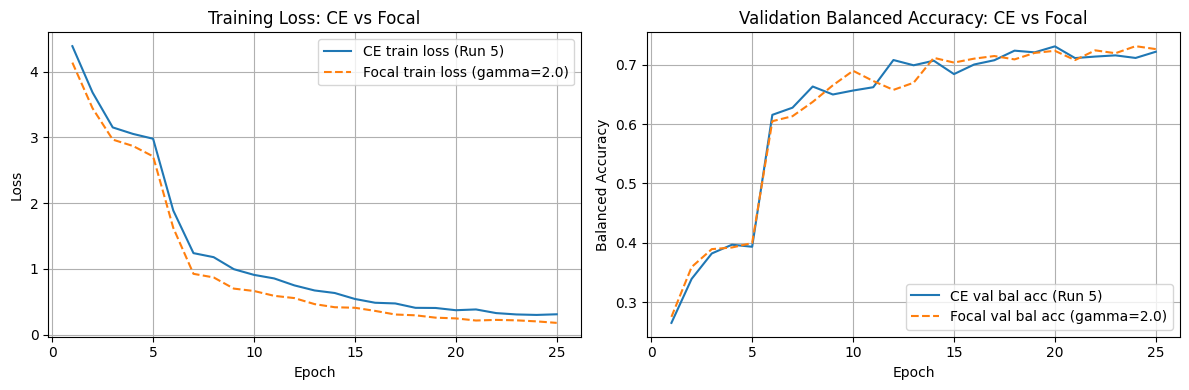

In [12]:
import torch.nn.functional as F

def focal_loss_fn(logits: torch.Tensor, targets: torch.Tensor, alpha: torch.Tensor, gamma: float = 2.0) -> torch.Tensor:
    """
    Alpha-balanced multi-class focal loss (Lin et al., ICCV 2017, arXiv:1708.02002).

    When gamma=0 reduces exactly to nn.CrossEntropyLoss(weight=alpha).

    Args:
        logits:  Raw model outputs, shape (N, C).
        targets: Ground-truth class indices, shape (N,).
        alpha:   Per-class weights, shape (C,), on same device as logits.
        gamma:   Focusing parameter. Lin et al. recommend gamma=2.

    Returns:
        Scalar mean focal loss.
    """
    log_p  = F.log_softmax(logits, dim=1)
    log_pt = log_p[torch.arange(len(targets)), targets]
    alpha_t = alpha[targets]

    if gamma == 0.0:
        return -(alpha_t * log_pt).mean()

    p_t = log_pt.exp()
    return -(alpha_t * (1.0 - p_t) ** gamma * log_pt).mean()


# ---------------------------------------------------------------------------
# Focal loss training loop (reuses train_one_epoch, evaluate, per_class_report)
# ---------------------------------------------------------------------------

def train_one_epoch_focal(model: nn.Module, loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, alpha: torch.Tensor,gamma: float) -> float:
    """
    One training epoch with focal loss.

    Args:
        model:     Model in train mode.
        loader:    Training DataLoader.
        optimizer: Optimizer.
        alpha:     Per-class focal weights on DEVICE.
        gamma:     Focal focusing parameter.

    Returns:
        Mean focal loss over the epoch.
    """
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = focal_loss_fn(model(images), labels, alpha, gamma)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_with_focal(model: nn.Module, loader: torch.utils.data.DataLoader, alpha: torch.Tensor, gamma: float) -> tuple[float, float, float]:
    """
    Evaluate model using focal loss.

    Returns:
        Tuple of (mean_focal_loss, accuracy, balanced_accuracy).
    """
    model.eval()
    all_preds:  list[np.ndarray] = []
    all_labels: list[np.ndarray] = []
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        total_loss += focal_loss_fn(logits, labels, alpha, gamma).item()
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return (
        total_loss / len(loader),
        float((all_preds == all_labels).mean()),
        float(balanced_accuracy_score(all_labels, all_preds)),
    )


def train_focal(model: nn.Module, train_loader: torch.utils.data.DataLoader, val_loader: torch.utils.data.DataLoader, class_weights: torch.Tensor,
                cfg: dict, gamma: float = 2.0) -> dict:
    """
    Training loop with focal loss, progressive unfreezing, and cosine LR.

    Identical structure to train() in section 5; only the loss function differs.
    class_weights are passed as alpha to focal_loss_fn.

    Args:
        model:         EfficientNet model.
        train_loader:  Training DataLoader.
        val_loader:    Validation DataLoader.
        class_weights: Per-class inverse-frequency weights on DEVICE (used as alpha).
        cfg:           Configuration dict.
        gamma:         Focal focusing parameter (default 2.0 per Lin et al., 2017).

    Returns:
        History dict with keys train_loss, val_loss, val_acc, val_bal_acc.
    """
    freeze_epochs = cfg["freeze_epochs"]
    total_epochs  = cfg["num_epochs"]

    _set_backbone_grad(model, False)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.get("lr_head", 1e-3),
        weight_decay=cfg["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=freeze_epochs, eta_min=1e-5,
    )

    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_acc": [], "val_bal_acc": []}
    best_bal_acc = 0.0

    for epoch in range(1, total_epochs + 1):
        if epoch == freeze_epochs + 1:
            _set_backbone_grad(model, True)
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"],
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=total_epochs - freeze_epochs, eta_min=1e-6,
            )
            print(f"  Backbone unfrozen at epoch {epoch}.")

        train_loss = train_one_epoch_focal(model, train_loader, optimizer, class_weights, gamma)
        scheduler.step()
        val_loss, val_acc, val_bal_acc = evaluate_with_focal(model, val_loader, class_weights, gamma)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_bal_acc"].append(val_bal_acc)

        print(
            f"Epoch {epoch:02d}/{total_epochs} | "
            f"focal_loss={train_loss:.4f} | "
            f"val_focal_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_bal_acc={val_bal_acc:.4f}"
        )

        if val_bal_acc > best_bal_acc:
            best_bal_acc = val_bal_acc
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_bal_acc": best_bal_acc,
                    "gamma": gamma,
                },
                cfg["ckpt_dir"] / "best_efficientnet_b0_focal_ham10000.pth",
            )
            print(f"  Checkpoint saved (val_bal_acc={best_bal_acc:.4f})")

    print(f"\nFocal loss experiment complete. Best val balanced accuracy: {best_bal_acc:.4f}")
    return history


# ---------------------------------------------------------------------------
# Run 6: focal loss, gamma=2.0, all other config identical to Run 5
# ---------------------------------------------------------------------------
GAMMA = 2.0
print(f"Focal loss experiment: gamma={GAMMA}, alpha from inverse class frequency")

model_focal = build_model(CFG["num_classes"]).to(DEVICE)

CFG_FOCAL = {**CFG, "resume_ckpt": None}

history_focal = train_focal(
    model_focal, train_loader, val_loader, class_weights, CFG_FOCAL, gamma=GAMMA,
)
#%%
# ---------------------------------------------------------------------------
# Per-epoch per-class recall at best focal checkpoint
# ---------------------------------------------------------------------------
ckpt_focal = torch.load(CFG["ckpt_dir"] / "best_efficientnet_b0_focal_ham10000.pth", map_location=DEVICE)
model_focal.load_state_dict(ckpt_focal["model_state_dict"])
print(
    f"Focal best checkpoint: epoch {ckpt_focal['epoch']}, "
    f"gamma={ckpt_focal['gamma']}, "
    f"val_bal_acc={ckpt_focal['val_bal_acc']:.4f}"
)
per_class_report(model_focal, val_loader)
#%%
# ---------------------------------------------------------------------------
# Focal vs CE training curves comparison
# ---------------------------------------------------------------------------
epochs_r5 = range(1, len(history["val_bal_acc"]) + 1)
epochs_fl = range(1, len(history_focal["val_bal_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_r5, history["train_loss"], label="CE train loss (Run 5)")
axes[0].plot(epochs_fl, history_focal["train_loss"], label=f"Focal train loss (gamma={GAMMA})", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss: CE vs Focal")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_r5, history["val_bal_acc"], label="CE val bal acc (Run 5)")
axes[1].plot(epochs_fl, history_focal["val_bal_acc"], label=f"Focal val bal acc (gamma={GAMMA})", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Validation Balanced Accuracy: CE vs Focal")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(Path("/kaggle/working") / "focal_vs_ce_curves.png", dpi=150)
plt.show()

## 10. EfficientNet-B3 experiment (Run 7)

EfficientNet-B3 backbone with all other config identical to Run 5.
B3 has ~12M parameters vs B0's ~5.3M, and a larger default input resolution
(300px), but img_size is kept at 224 to isolate the backbone variable.
drop_rate=0.4 is set explicitly to match Run 5's regularisation intent;
timm's B3 default is 0.3.


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNet-B3 trainable parameters: 10,706,991
EfficientNet-B0 trainable parameters (Run 5): 4,016,515
Epoch 01/25 | train_loss=4.0110 | val_loss=2.0412 | val_acc=0.4020 | val_bal_acc=0.2785
  Checkpoint saved (val_bal_acc=0.2785)
Epoch 02/25 | train_loss=3.2869 | val_loss=1.9099 | val_acc=0.4341 | val_bal_acc=0.3314
  Checkpoint saved (val_bal_acc=0.3314)
Epoch 03/25 | train_loss=2.8638 | val_loss=1.8261 | val_acc=0.4511 | val_bal_acc=0.3732
  Checkpoint saved (val_bal_acc=0.3732)
Epoch 04/25 | train_loss=2.8063 | val_loss=1.6402 | val_acc=0.5068 | val_bal_acc=0.3815
  Checkpoint saved (val_bal_acc=0.3815)
Epoch 05/25 | train_loss=2.6950 | val_loss=1.7299 | val_acc=0.4767 | val_bal_acc=0.3880
  Checkpoint saved (val_bal_acc=0.3880)
  Backbone unfrozen at epoch 6.
Epoch 06/25 | train_loss=1.7685 | val_loss=0.8739 | val_acc=0.6687 | val_bal_acc=0.6118
  Checkpoint saved (val_bal_acc=0.6118)
Epoch 07/25 | train_loss=1.1545 | val_loss=1.1977 | val_acc=0.6471 | val_bal_acc=0.6752
  Check

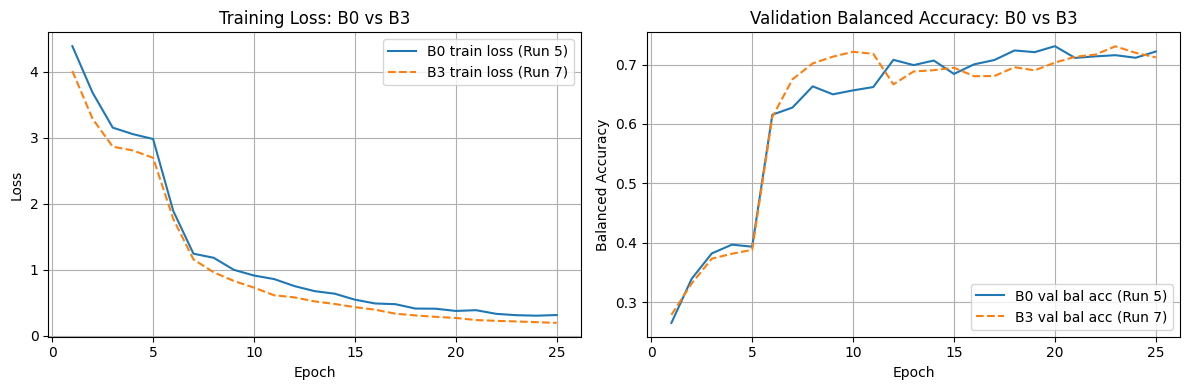

In [13]:

def build_model_b3(num_classes: int) -> nn.Module:
    """
    Load EfficientNet-B3 pretrained on ImageNet with the classification head
    replaced for num_classes output classes.

    drop_rate=0.4 matches Run 5's EfficientNet-B0 configuration. timm's B3
    default is 0.3; setting it explicitly avoids a silent regularisation change.

    Args:
        num_classes: Number of output classes.

    Returns:
        EfficientNet-B3 model ready for fine-tuning.
    """
    return timm.create_model(
        "efficientnet_b3",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.4,
    )


model_b3 = build_model_b3(CFG["num_classes"]).to(DEVICE)
n_params_b3 = sum(p.numel() for p in model_b3.parameters() if p.requires_grad)
n_params_b0 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"EfficientNet-B3 trainable parameters: {n_params_b3:,}")
print(f"EfficientNet-B0 trainable parameters (Run 5): {n_params_b0:,}")
#%%
# ---------------------------------------------------------------------------
# Run 7: EfficientNet-B3, weighted CE, all other config identical to Run 5
# ---------------------------------------------------------------------------
CFG_B3 = {**CFG, "resume_ckpt": None}

history_b3 = train(model_b3, train_loader, val_loader, class_weights, CFG_B3)
#%%
# ---------------------------------------------------------------------------
# Per-class recall at best B3 checkpoint
# ---------------------------------------------------------------------------
ckpt_b3 = torch.load(
    CFG["ckpt_dir"] / "best_efficientnet_b0_ham10000.pth",
    map_location=DEVICE,
)
# Note: the checkpoint filename uses the default name from train(); rename if running
# both B0 and B3 experiments in the same session to avoid overwriting.
model_b3.load_state_dict(ckpt_b3["model_state_dict"])
print(
    f"B3 best checkpoint: epoch {ckpt_b3['epoch']}, "
    f"val_bal_acc={ckpt_b3['val_bal_acc']:.4f}"
)
per_class_report(model_b3, val_loader)
#%%
# ---------------------------------------------------------------------------
# B0 vs B3 training curves comparison
# ---------------------------------------------------------------------------
epochs_b0 = range(1, len(history["val_bal_acc"]) + 1)
epochs_b3 = range(1, len(history_b3["val_bal_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_b0, history["train_loss"],    label="B0 train loss (Run 5)")
axes[0].plot(epochs_b3, history_b3["train_loss"], label="B3 train loss (Run 7)", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss: B0 vs B3")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_b0, history["val_bal_acc"],    label="B0 val bal acc (Run 5)")
axes[1].plot(epochs_b3, history_b3["val_bal_acc"], label="B3 val bal acc (Run 7)", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Validation Balanced Accuracy: B0 vs B3")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(Path("/kaggle/working") / "b0_vs_b3_curves.png", dpi=150)
plt.show()